In [2]:

# ============================================================
# IMPORTS
# ============================================================


from pathlib import Path

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")

In [5]:
# ============================================================
# PROJECT PATHS
# ============================================================


project_root = Path.cwd().parent


feature_dir = (
    project_root
    / "data"
    / "processed"
    / "feature_engineered"
)


model_dir = (
    project_root
    / "models"
)


model_dir.mkdir(
    exist_ok=True
)


print(project_root)

c:\Users\ujjwa\OneDrive\Documents\beauty-recommender


In [3]:
# ============================================================
# LOAD DATA
# ============================================================


products = pd.read_csv(
    feature_dir / "products_features.csv"
)


reviews = pd.read_csv(
    feature_dir / "reviews_features.csv"
)


print(
    "Products shape:",
    products.shape
)


print(
    "Reviews shape:",
    reviews.shape
)

Products shape: (8494, 32)
Reviews shape: (1088891, 24)


In [4]:
reviews.head()

,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,...,product_id,product_name,brand_name,price_usd,positive_signal,engagement_score,review_length,recency_days,time_weight,interaction_strength
0,538863,1,0.0,NaN,0,0,0,2018-11-01,One use and into the trash this went. I woke u...,one and done,...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,0,0,177,1601,0.000624,0.000624
1,549704,5,NaN,1.0,3,0,3,2011-04-21,I like this a lot. I was a little afraid to tr...,Sweet!,...,P218700,100 percent Pure Argan Oil,Josie Maran,49.0,1,3,284,4352,0.000230,0.004595
2,557770,5,NaN,1.0,1,0,1,2016-02-19,It is ugly and smelly - but this product works...,Sulfur Rules!,...,P232903,EradiKate Acne Treatment,Kate Somerville,28.0,1,1,254,2587,0.000386,0.003864
3,562130,5,NaN,1.0,3,0,3,2014-11-29,Can’t go wrong with this basic moisturizer. I ...,Good Basic Moisterizer,...,P381030,Dramatically Different Moisturizing Lotion+,CLINIQUE,32.5,1,3,165,3034,0.000329,0.006590
4,582399,5,1.0,NaN,0,0,0,2018-11-21,I got a sample of this in the k beauty play se...,NaN,...,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,1,0,256,1581,0.000632,0.003161


In [5]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1088891 entries, 0 to 1088890
Data columns (total 24 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   author_id                 1088891 non-null  object 
 1   rating                    1088891 non-null  int64  
 2   is_recommended            924416 non-null   float64
 3   helpfulness               530535 non-null   float64
 4   total_feedback_count      1088891 non-null  int64  
 5   total_neg_feedback_count  1088891 non-null  int64  
 6   total_pos_feedback_count  1088891 non-null  int64  
 7   submission_time           1088891 non-null  object 
 8   review_text               1087450 non-null  object 
 9   review_title              779152 non-null   object 
 10  skin_tone                 1088891 non-null  object 
 11  eye_color                 1088891 non-null  object 
 12  skin_type                 1088891 non-null  object 
 13  hair_color                1

In [6]:
reviews["is_recommended"].value_counts()

is_recommended
1.0    776460
0.0    147956
Name: count, dtype: int64

In [7]:
reviews["is_recommended"].value_counts(
    normalize=True
)

is_recommended
1.0    0.839947
0.0    0.160053
Name: proportion, dtype: float64

In [8]:
# ============================================================
# DATATYPE CLEANING
# ============================================================


reviews["author_id"] = (
    reviews["author_id"]
    .astype("string")
)


reviews["product_id"] = (
    reviews["product_id"]
    .astype("string")
)


products["product_id"] = (
    products["product_id"]
    .astype("string")
)


reviews["submission_time"] = pd.to_datetime(
    reviews["submission_time"]
)

In [9]:
# ============================================================
# SORT BY TIME
# ============================================================


reviews = (
    reviews
    .sort_values(
        "submission_time"
    )
    .reset_index(drop=True)
)

In [10]:
products.columns.tolist()

['product_id',
 'product_name',
 'brand_id',
 'brand_name',
 'loves_count',
 'rating',
 'reviews',
 'size',
 'variation_type',
 'variation_value',
 'variation_desc',
 'ingredients',
 'price_usd',
 'value_price_usd',
 'sale_price_usd',
 'limited_edition',
 'new',
 'online_only',
 'out_of_stock',
 'sephora_exclusive',
 'highlights',
 'primary_category',
 'secondary_category',
 'tertiary_category',
 'child_count',
 'child_max_price',
 'child_min_price',
 'log_price',
 'discount_amount',
 'discount_pct',
 'popularity_score',
 'text_blob']

In [11]:
# ============================================================
# PRODUCT FEATURES
# ============================================================


product_columns = [

    "product_id",

    "price_usd",

    "log_price",

    "discount_amount",

    "discount_pct",

    "popularity_score",

    "primary_category",

    "secondary_category",

    "tertiary_category",

    "brand_name",

    "new",

    "limited_edition",

    "online_only",

    "out_of_stock"

]


product_features = (
    products[
        product_columns
    ]
)

In [12]:
# ============================================================
# REMOVE EXISTING PRODUCT COLUMNS
# ============================================================


reviews = reviews.drop(
    columns=[
        "price_usd",
        "brand_name"
    ],
    errors="ignore"
)

In [13]:
# ============================================================
# MERGE PRODUCT INFORMATION
# ============================================================


reviews = reviews.merge(
    product_features,
    on="product_id",
    how="left"
)


reviews = (
    reviews
    .sort_values(
        "submission_time"
    )
    .reset_index(drop=True)
)


print(
    reviews.shape
)

(1088891, 35)


In [14]:
# ============================================================
# REVIEW FEATURES
# ============================================================


reviews["review_text"] = (
    reviews["review_text"]
    .fillna("")
)


reviews["review_length"] = (
    reviews["review_text"]
    .str.len()
)


reviews["review_word_count"] = (
    reviews["review_text"]
    .str.split()
    .str.len()
)


reviews["exclamation_count"] = (
    reviews["review_text"]
    .str.count("!")
)


reviews["uppercase_ratio"] = (

    reviews["review_text"]
    .apply(
        lambda x:
        sum(
            c.isupper()
            for c in x
        )
        /
        max(len(x),1)
    )

)

In [15]:
# ============================================================
# USER HISTORY
# ============================================================


reviews["user_previous_review_count"] = (

    reviews
    .groupby("author_id")
    .cumcount()

)

In [16]:
reviews["user_previous_avg_price"] = (

    reviews
    .groupby("author_id")["price_usd"]
    .apply(
        lambda x:
        x.shift()
        .expanding()
        .mean()
    )
    .reset_index(
        level=0,
        drop=True
    )

)

In [17]:
reviews["user_price_difference"] = (

    reviews["price_usd"]

    -

    reviews["user_previous_avg_price"]

)

In [18]:
reviews["user_previous_avg_review_length"] = (

    reviews
    .groupby("author_id")["review_length"]
    .apply(
        lambda x:
        x.shift()
        .expanding()
        .mean()
    )
    .reset_index(
        level=0,
        drop=True
    )

)

In [19]:
global_price = reviews["price_usd"].mean()


reviews["user_previous_avg_price"] = (

    reviews["user_previous_avg_price"]
    .fillna(global_price)

)


reviews["user_previous_avg_review_length"] = (

    reviews["user_previous_avg_review_length"]
    .fillna(
        reviews["review_length"].mean()
    )

)

In [20]:
# ============================================================
# PRODUCT HISTORY
# ============================================================


reviews["product_previous_review_count"] = (

    reviews
    .groupby("product_id")
    .cumcount()

)

In [21]:
reviews["product_previous_recommend_rate"] = (

    reviews
    .groupby("product_id")["is_recommended"]
    .apply(
        lambda x:
        x.shift()
        .expanding()
        .mean()
    )
    .reset_index(
        level=0,
        drop=True
    )

)

In [22]:
global_rec_rate = (
    reviews["is_recommended"]
    .mean()
)


reviews["product_previous_recommend_rate"] = (

    reviews["product_previous_recommend_rate"]
    .fillna(global_rec_rate)

)

In [23]:
# ============================================================
# BRAND HISTORY
# ============================================================


reviews["brand_previous_review_count"] = (

    reviews
    .groupby("brand_name")
    .cumcount()

)

In [24]:
reviews["brand_previous_recommend_rate"] = (

    reviews
    .groupby("brand_name")["is_recommended"]
    .apply(
        lambda x:
        x.shift()
        .expanding()
        .mean()
    )
    .reset_index(
        level=0,
        drop=True
    )

)


reviews["brand_previous_recommend_rate"] = (

    reviews["brand_previous_recommend_rate"]
    .fillna(global_rec_rate)

)

In [25]:
# ============================================================
# USER BRAND INTERACTION
# ============================================================


reviews["user_brand_previous_count"] = (

    reviews
    .groupby(
        [
            "author_id",
            "brand_name"
        ]
    )
    .cumcount()

)

In [26]:
# ============================================================
# OPTIMIZED USER-BRAND FEATURE
# ============================================================


group_cols = [
    "author_id",
    "brand_name"
]


previous_sum = (
    reviews
    .groupby(group_cols)["is_recommended"]
    .cumsum()
    -
    reviews["is_recommended"]
)


previous_count = (
    reviews
    .groupby(group_cols)
    .cumcount()
)


reviews["user_brand_previous_recommend_rate"] = (

    previous_sum
    /
    previous_count.replace(0,np.nan)

)


reviews["user_brand_previous_recommend_rate"] = (

    reviews["user_brand_previous_recommend_rate"]
    .fillna(global_rec_rate)

)



In [27]:
# ============================================================
# USER CATEGORY PREFERENCE
# ============================================================


reviews["user_category_previous_count"] = (

    reviews
    .groupby(
        [
            "author_id",
            "primary_category"
        ]
    )
    .cumcount()

)

In [28]:
# ============================================================
# FAST USER-CATEGORY HISTORICAL RECOMMEND RATE
# ============================================================


group_cols = [
    "author_id",
    "primary_category"
]


previous_sum = (

    reviews
    .groupby(group_cols)["is_recommended"]
    .cumsum()

    -

    reviews["is_recommended"]

)


previous_count = (

    reviews
    .groupby(group_cols)
    .cumcount()

)


reviews["user_category_previous_recommend_rate"] = (

    previous_sum
    /
    previous_count.replace(
        0,
        np.nan
    )

)


reviews["user_category_previous_recommend_rate"] = (

    reviews["user_category_previous_recommend_rate"]
    .fillna(
        global_rec_rate
    )

)

In [29]:
reviews.shape

(1088891, 50)

In [30]:
reviews.columns.tolist()

['author_id',
 'rating',
 'is_recommended',
 'helpfulness',
 'total_feedback_count',
 'total_neg_feedback_count',
 'total_pos_feedback_count',
 'submission_time',
 'review_text',
 'review_title',
 'skin_tone',
 'eye_color',
 'skin_type',
 'hair_color',
 'product_id',
 'product_name',
 'positive_signal',
 'engagement_score',
 'review_length',
 'recency_days',
 'time_weight',
 'interaction_strength',
 'price_usd',
 'log_price',
 'discount_amount',
 'discount_pct',
 'popularity_score',
 'primary_category',
 'secondary_category',
 'tertiary_category',
 'brand_name',
 'new',
 'limited_edition',
 'online_only',
 'out_of_stock',
 'review_word_count',
 'exclamation_count',
 'uppercase_ratio',
 'user_previous_review_count',
 'user_previous_avg_price',
 'user_price_difference',
 'user_previous_avg_review_length',
 'product_previous_review_count',
 'product_previous_recommend_rate',
 'brand_previous_review_count',
 'brand_previous_recommend_rate',
 'user_brand_previous_count',
 'user_brand_previo

In [31]:
# ============================================================
# REMOVE LEAKAGE + UNUSED COLUMNS
# ============================================================


drop_columns = [

    # IDs
    "author_id",
    "product_id",

    # Target leakage
    "rating",
    "helpfulness",

    "total_feedback_count",
    "total_neg_feedback_count",
    "total_pos_feedback_count",

    "positive_signal",
    "interaction_strength",

    # Raw text
    "review_text",
    "review_title",

    # Product name
    "product_name",

    # Timestamp
    "submission_time"

]

In [32]:
# ============================================================
# FINAL ML DATASET
# ============================================================


ml_df = reviews.drop(
    columns=drop_columns,
    errors="ignore"
)


print(
    ml_df.shape
)


ml_df.head()

(1088891, 37)


,is_recommended,skin_tone,eye_color,skin_type,hair_color,engagement_score,review_length,recency_days,time_weight,price_usd,...,user_price_difference,user_previous_avg_review_length,product_previous_review_count,product_previous_recommend_rate,brand_previous_review_count,brand_previous_recommend_rate,user_brand_previous_count,user_brand_previous_recommend_rate,user_category_previous_count,user_category_previous_recommend_rate
0,NaN,light,Unknown,combination,Unknown,13,743,5318,0.000188,39.0,...,NaN,320.223245,0,0.839947,0,0.839947,0,0.839947,0,0.839947
1,NaN,light,Unknown,combination,Unknown,7,343,5318,0.000188,39.0,...,NaN,320.223245,0,0.839947,0,0.839947,0,0.839947,0,0.839947
2,NaN,light,Unknown,combination,Unknown,13,743,5318,0.000188,12.0,...,-27.0,743.000000,0,0.839947,1,0.839947,1,0.839947,1,0.839947
3,NaN,dark,Unknown,dry,Unknown,0,321,5317,0.000188,49.0,...,NaN,320.223245,0,0.839947,0,0.839947,0,0.839947,0,0.839947
4,NaN,fair,Unknown,oily,Unknown,0,206,5317,0.000188,23.5,...,NaN,320.223245,0,0.839947,0,0.839947,0,0.839947,0,0.839947


In [33]:
ml_df.columns.tolist()

['is_recommended',
 'skin_tone',
 'eye_color',
 'skin_type',
 'hair_color',
 'engagement_score',
 'review_length',
 'recency_days',
 'time_weight',
 'price_usd',
 'log_price',
 'discount_amount',
 'discount_pct',
 'popularity_score',
 'primary_category',
 'secondary_category',
 'tertiary_category',
 'brand_name',
 'new',
 'limited_edition',
 'online_only',
 'out_of_stock',
 'review_word_count',
 'exclamation_count',
 'uppercase_ratio',
 'user_previous_review_count',
 'user_previous_avg_price',
 'user_price_difference',
 'user_previous_avg_review_length',
 'product_previous_review_count',
 'product_previous_recommend_rate',
 'brand_previous_review_count',
 'brand_previous_recommend_rate',
 'user_brand_previous_count',
 'user_brand_previous_recommend_rate',
 'user_category_previous_count',
 'user_category_previous_recommend_rate']

In [34]:
# ============================================================
# MISSING VALUES
# ============================================================


numeric_cols = ml_df.select_dtypes(
    include=np.number
).columns


ml_df[numeric_cols] = (

    ml_df[numeric_cols]
    .fillna(0)

)

In [35]:
categorical_cols = ml_df.select_dtypes(
    include=["object","string"]
).columns


ml_df[categorical_cols] = (

    ml_df[categorical_cols]
    .fillna("Unknown")

)

In [36]:
leak_words = [
    "rating",
    "positive",
    "feedback",
    "recommend",
    "interaction",
    "helpfulness"
]


for word in leak_words:

    print(
        word,
        [
            c for c in ml_df.columns
            if word in c.lower()
        ]
    )

rating []
positive []
feedback []
recommend ['is_recommended', 'product_previous_recommend_rate', 'brand_previous_recommend_rate', 'user_brand_previous_recommend_rate', 'user_category_previous_recommend_rate']
interaction []
helpfulness []


In [37]:
# ============================================================
# SAVE
# ============================================================


ml_ready_dir = (
    project_root
    /
    "data"
    /
    "processed"
    /
    "ml_ready"
)


ml_ready_dir.mkdir(
    parents=True,
    exist_ok=True
)


ml_df.to_csv(
    ml_ready_dir /
    "recommendation_classification_features.csv",
    index=False
)

In [38]:
# ============================================================
# SPLIT FEATURES AND TARGET
# ============================================================


X = ml_df.drop(
    columns=[
        "is_recommended"
    ]
)


y = ml_df["is_recommended"]


print(
    X.shape
)


print(
    y.shape
)

(1088891, 36)
(1088891,)


In [39]:
y.value_counts()

is_recommended
1.0    776460
0.0    312431
Name: count, dtype: int64

In [40]:
y.value_counts(normalize=True)

is_recommended
1.0    0.713074
0.0    0.286926
Name: proportion, dtype: float64

In [ ]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================


from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)


print(X_train.shape)
print(X_test.shape)

(871112, 36)
(217779, 36)


In [42]:
# ============================================================
# COLUMN TYPES
# ============================================================


categorical_cols = X_train.select_dtypes(
    include=[
        "object",
        "string"
    ]
).columns.tolist()


numerical_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()



print(
    "Categorical:",
    categorical_cols
)


print(
    "Numerical:",
    numerical_cols
)

Categorical: ['skin_tone', 'eye_color', 'skin_type', 'hair_color', 'primary_category', 'secondary_category', 'tertiary_category', 'brand_name']
Numerical: ['engagement_score', 'review_length', 'recency_days', 'time_weight', 'price_usd', 'log_price', 'discount_amount', 'discount_pct', 'popularity_score', 'new', 'limited_edition', 'online_only', 'out_of_stock', 'review_word_count', 'exclamation_count', 'uppercase_ratio', 'user_previous_review_count', 'user_previous_avg_price', 'user_price_difference', 'user_previous_avg_review_length', 'product_previous_review_count', 'product_previous_recommend_rate', 'brand_previous_review_count', 'brand_previous_recommend_rate', 'user_brand_previous_count', 'user_brand_previous_recommend_rate', 'user_category_previous_count', 'user_category_previous_recommend_rate']


In [43]:
# ============================================================
# PREPROCESSING
# ============================================================


from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)


preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numerical_cols
        ),


        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )

    ]

)

In [44]:
# ============================================================
# DUMMY BASELINE
# ============================================================


from sklearn.dummy import DummyClassifier

from sklearn.pipeline import Pipeline


dummy_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),


        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )

    ]

)

In [45]:
dummy_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
dummy_pred = dummy_pipeline.predict(
    X_test
)


dummy_prob = dummy_pipeline.predict_proba(
    X_test
)[:,1]

In [47]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================


from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    classification_report

)



def evaluate_model(
    name,
    y_true,
    pred,
    prob
):

    results = {

        "Model":
        name,


        "Accuracy":
        accuracy_score(
            y_true,
            pred
        ),


        "Precision":
        precision_score(
            y_true,
            pred
        ),


        "Recall":
        recall_score(
            y_true,
            pred
        ),


        "F1":
        f1_score(
            y_true,
            pred
        ),


        "ROC-AUC":
        roc_auc_score(
            y_true,
            prob
        )

    }


    print(
        classification_report(
            y_true,
            pred
        )
    )


    return results

In [48]:
dummy_results = evaluate_model(

    "Dummy Baseline",

    y_test,

    dummy_pred,

    dummy_prob

)


dummy_results

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00     62486
         1.0       0.71      1.00      0.83    155293

    accuracy                           0.71    217779
   macro avg       0.36      0.50      0.42    217779
weighted avg       0.51      0.71      0.59    217779



{'Model': 'Dummy Baseline',
 'Accuracy': 0.7130761000831117,
 'Precision': 0.7130761000831117,
 'Recall': 1.0,
 'F1': 0.8325095423939615,
 'ROC-AUC': 0.5}

In [49]:
dummy_results = evaluate_model(

    "Dummy Baseline",

    y_test,

    dummy_pred,

    dummy_prob

)


dummy_results

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00     62486
         1.0       0.71      1.00      0.83    155293

    accuracy                           0.71    217779
   macro avg       0.36      0.50      0.42    217779
weighted avg       0.51      0.71      0.59    217779



{'Model': 'Dummy Baseline',
 'Accuracy': 0.7130761000831117,
 'Precision': 0.7130761000831117,
 'Recall': 1.0,
 'F1': 0.8325095423939615,
 'ROC-AUC': 0.5}

In [50]:
results = []

results.append(
    dummy_results
)

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================


lr_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),


        (
            "model",

            LogisticRegression(

                max_iter=1000,

                class_weight="balanced",

                random_state=42

            )

        )

    ]

)

In [53]:
lr_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
lr_pred = lr_pipeline.predict(
    X_test
)


lr_prob = lr_pipeline.predict_proba(
    X_test
)[:,1]

In [55]:
lr_results = evaluate_model(

    "Logistic Regression",

    y_test,

    lr_pred,

    lr_prob

)


results.append(
    lr_results
)

              precision    recall  f1-score   support

         0.0       0.72      0.73      0.73     62486
         1.0       0.89      0.88      0.89    155293

    accuracy                           0.84    217779
   macro avg       0.80      0.81      0.81    217779
weighted avg       0.84      0.84      0.84    217779



In [56]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy Baseline,0.713076,0.713076,1.000000,0.832510,0.500000
1,Logistic Regression,0.840352,0.891882,0.883176,0.887508,0.897998


In [57]:
# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier

In [58]:
rf_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",

            RandomForestClassifier(

                n_estimators=200,

                max_depth=20,

                min_samples_split=5,

                min_samples_leaf=2,

                random_state=42,

                class_weight="balanced",

                n_jobs=-1

            )

        )

    ]

)

In [59]:
#*3rf_pipeline.fit(
    #X_train,
#y_train*#

KeyboardInterrupt: 

In [ ]:
results_df = (
    pd.DataFrame(results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.882716,0.896736,0.944260,0.919885,0.932268
1,Logistic Regression,0.840352,0.891882,0.883176,0.887508,0.897998
0,Dummy Baseline,0.713076,0.713076,1.000000,0.832510,0.500000


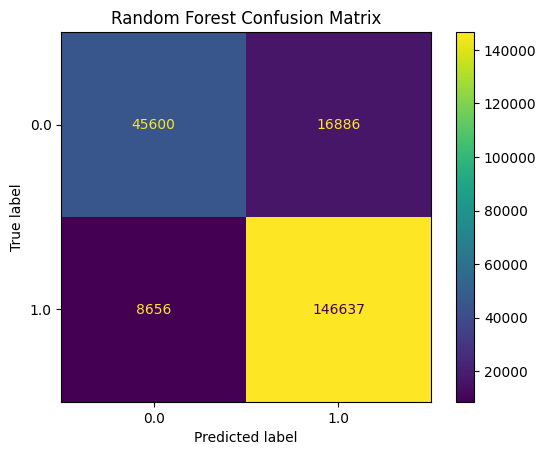

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

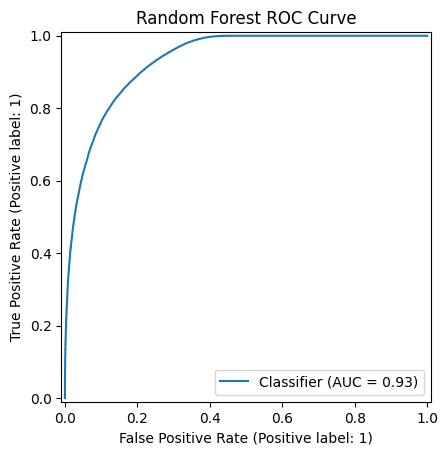

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob
)

plt.title("Random Forest ROC Curve")
plt.show()

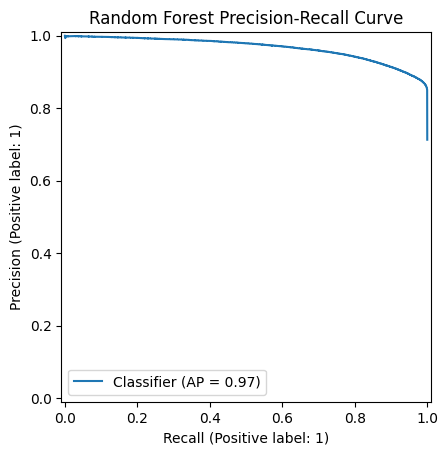

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_prob
)

plt.title("Random Forest Precision-Recall Curve")
plt.show()

In [ ]:
feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
    rf_pipeline.named_steps[
        "model"
    ].feature_importances_

})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance.head(20)

,Feature,Importance
3,num__time_weight,0.157189
2,num__recency_days,0.127354
21,num__product_previous_recommend_rate,0.081608
44,cat__eye_color_Unknown,0.074232
14,num__exclamation_count,0.064438
25,num__user_brand_previous_recommend_rate,0.062501
55,cat__hair_color_Unknown,0.062487
27,num__user_category_previous_recommend_rate,0.058403
23,num__brand_previous_recommend_rate,0.037712
0,num__engagement_score,0.031309


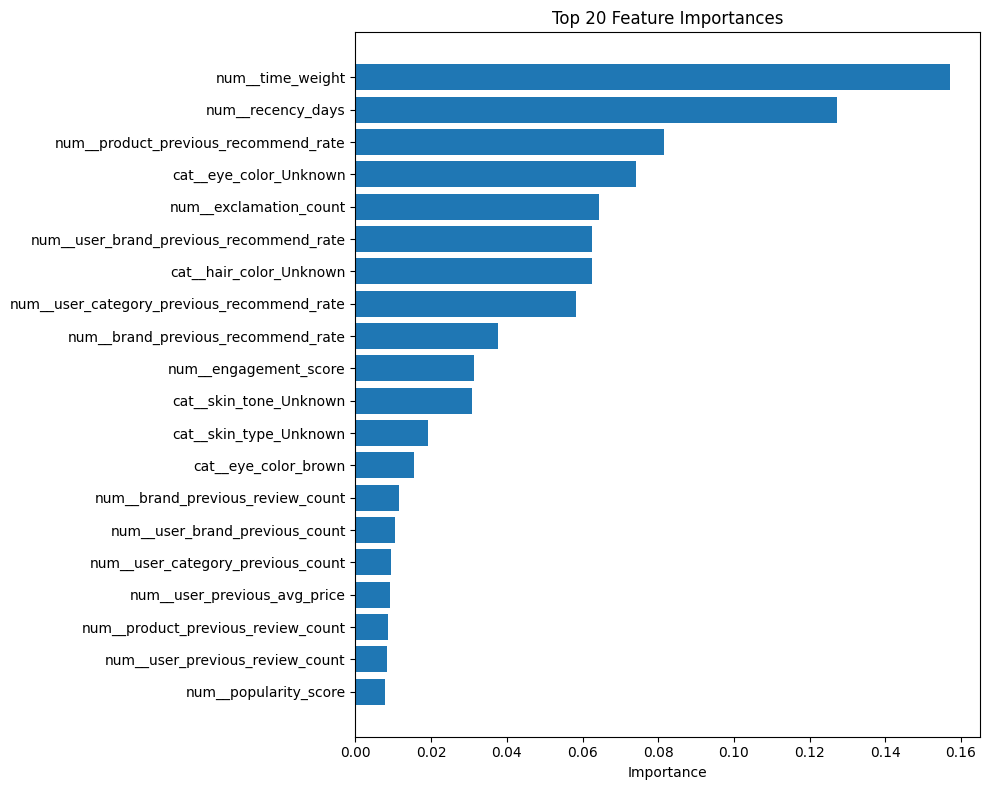

In [ ]:
top_features = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importances")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

In [ ]:
gb_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",

            GradientBoostingClassifier(

                n_estimators=200,

                learning_rate=0.05,

                max_depth=5,

                random_state=42

            )

        )

    ]

)

In [ ]:
print(X_train.shape)
print(len(numerical_cols), len(categorical_cols))

(871112, 36)
28 8


In [ ]:
print(preprocessor.fit_transform(X_train).shape)

(871112, 250)


In [60]:
%pip install xgboost


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
from xgboost import XGBClassifier

In [62]:
xgb_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",

            XGBClassifier(

                n_estimators=300,

                learning_rate=0.05,

                max_depth=6,

                subsample=0.8,

                colsample_bytree=0.8,
                tree_method="hist",


                eval_metric="logloss",

                random_state=42,

                n_jobs=-1

            )

        )

    ]

)

In [64]:
xgb_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
xgb_pred = xgb_pipeline.predict(
    X_test
)

xgb_prob = xgb_pipeline.predict_proba(
    X_test
)[:,1]

In [66]:
xgb_results = evaluate_model(

    "XGBoost",

    y_test,

    xgb_pred,

    xgb_prob

)

results.append(
    xgb_results
)

              precision    recall  f1-score   support

         0.0       0.93      0.67      0.78     62486
         1.0       0.88      0.98      0.93    155293

    accuracy                           0.89    217779
   macro avg       0.90      0.82      0.85    217779
weighted avg       0.89      0.89      0.88    217779



In [67]:
results_df = (

    pd.DataFrame(results)

    .sort_values(

        "ROC-AUC",

        ascending=False

    )

)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.890187,0.880996,0.978125,0.927023,0.935964
1,Logistic Regression,0.840352,0.891882,0.883176,0.887508,0.897998
0,Dummy Baseline,0.713076,0.713076,1.000000,0.832510,0.500000


In [68]:
from sklearn.model_selection import train_test_split

X_train_tune, _, y_train_tune, _ = train_test_split(

    X_train,

    y_train,

    train_size=200000,

    stratify=y_train,

    random_state=42

)

print(X_train_tune.shape)

(200000, 36)


In [69]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {

    "model__n_estimators":[200,300,400],

    "model__max_depth":[4,6,8],

    "model__learning_rate":[0.03,0.05,0.1],

    "model__subsample":[0.8,1.0],

    "model__colsample_bytree":[0.8,1.0],

    "model__min_child_weight":[1,3,5]

}

xgb_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=param_grid,

    n_iter=5,

    cv=3,

    scoring="roc_auc",

    random_state=42,

    verbose=2,

    n_jobs=-1

)

xgb_search.fit(

    X_train_tune,

    y_train_tune

)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [4, 6, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,n_iter,5
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [70]:
print(xgb_search.best_params_)
print("Best CV ROC-AUC:", xgb_search.best_score_)

{'model__subsample': 1.0, 'model__n_estimators': 400, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Best CV ROC-AUC: 0.9344402276075962


In [50]:
best_xgb = xgb_search.best_estimator_

best_xgb.fit(

    X_train,

    y_train

)

NameError: name 'xgb_search' is not defined

In [72]:
best_pred = best_xgb.predict(X_test)

best_prob = best_xgb.predict_proba(
    X_test
)[:,1]

In [73]:
best_results = evaluate_model(

    "Tuned XGBoost",

    y_test,

    best_pred,

    best_prob

)

results.append(best_results)

results_df = (

    pd.DataFrame(results)

    .sort_values(

        "ROC-AUC",

        ascending=False

    )

)

results_df

              precision    recall  f1-score   support

         0.0       0.92      0.68      0.78     62486
         1.0       0.88      0.98      0.93    155293

    accuracy                           0.89    217779
   macro avg       0.90      0.83      0.86    217779
weighted avg       0.89      0.89      0.89    217779



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,Tuned XGBoost,0.892047,0.884680,0.975807,0.928012,0.938348
2,XGBoost,0.890187,0.880996,0.978125,0.927023,0.935964
1,Logistic Regression,0.840352,0.891882,0.883176,0.887508,0.897998
0,Dummy Baseline,0.713076,0.713076,1.000000,0.832510,0.500000


In [74]:
from sklearn.model_selection import cross_validate

cv_scores = cross_validate(

    best_xgb,

    X_train_tune,

    y_train_tune,

    cv=5,

    scoring={

        "Accuracy":"accuracy",

        "Precision":"precision",

        "Recall":"recall",

        "F1":"f1",

        "ROC_AUC":"roc_auc"

    },

    n_jobs=-1

)

print("Accuracy :", cv_scores["test_Accuracy"].mean())
print("Precision:", cv_scores["test_Precision"].mean())
print("Recall   :", cv_scores["test_Recall"].mean())
print("F1       :", cv_scores["test_F1"].mean())
print("ROC-AUC  :", cv_scores["test_ROC_AUC"].mean())

Accuracy : 0.89008
Precision: 0.8847077835032856
Recall   : 0.9725975528520842
F1       : 0.9265727817271117
ROC-AUC  : 0.9349886855379406


In [75]:
feature_names = (

    best_xgb
    .named_steps["preprocessor"]
    .get_feature_names_out()

)

importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
    best_xgb.named_steps[
        "model"
    ].feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
3,num__time_weight,0.414112
14,num__exclamation_count,0.089318
25,num__user_brand_previous_recommend_rate,0.048215
27,num__user_category_previous_recommend_rate,0.030003
69,cat__secondary_category_Mini Size,0.017837
21,num__product_previous_recommend_rate,0.015650
231,cat__brand_name_The Ordinary,0.015148
0,num__engagement_score,0.014826
44,cat__eye_color_Unknown,0.011605
135,cat__brand_name_Drunk Elephant,0.009263


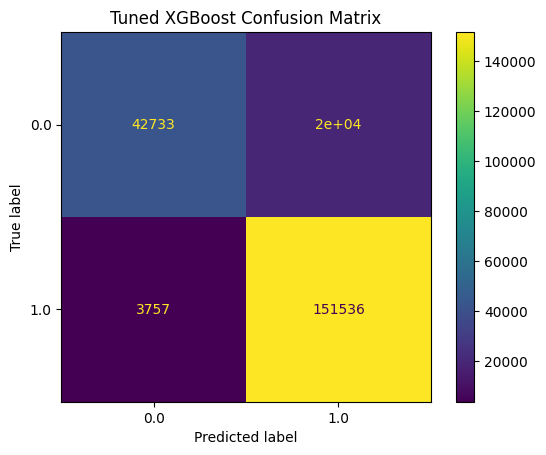

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(

    y_test,

    best_pred

)

plt.title("Tuned XGBoost Confusion Matrix")

plt.show()

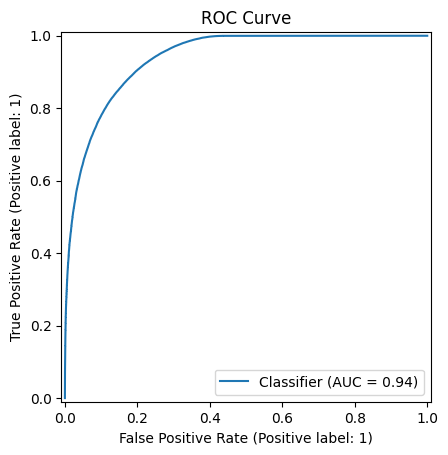

In [77]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(

    y_test,

    best_prob

)

plt.title("ROC Curve")

plt.show()

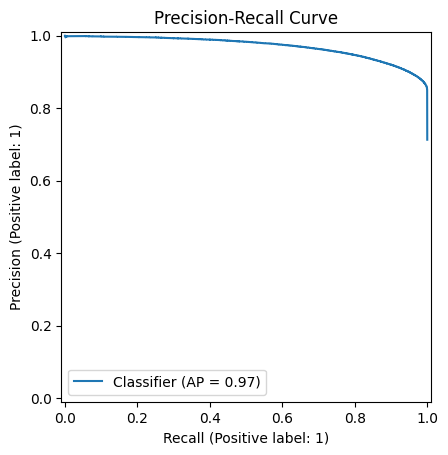

In [78]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(

    y_test,

    best_prob

)

plt.title("Precision-Recall Curve")

plt.show()

In [79]:
reviews.groupby(
    "is_recommended"
)["time_weight"].mean()

is_recommended
0.0    0.004789
1.0    0.004666
Name: time_weight, dtype: float64

In [80]:
ml_df.groupby(
    "is_recommended"
)["time_weight"].describe()

,count,mean,std,min,25%,50%,75%,max
is_recommended,,,,,,,,
0.0,312431.0,0.002447,0.019518,0.000188,0.000328,0.000481,0.001047,1.0
1.0,776460.0,0.004666,0.023751,0.000491,0.000778,0.001179,0.002347,1.0


In [81]:
ml_df.groupby(
    "is_recommended"
)["recency_days"].describe()

,count,mean,std,min,25%,50%,75%,max
is_recommended,,,,,,,,
0.0,312431.0,2119.412360,1388.317173,0.0,954.0,2076.0,3046.0,5318.0
1.0,776460.0,881.100701,535.686217,0.0,425.0,847.0,1285.0,2034.0


In [82]:
ml_df.groupby(
    "is_recommended"
)["engagement_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_recommended,,,,,,,,
0.0,312431.0,2.907035,19.766590,-1096.0,0.0,0.0,3.0,4729.0
1.0,776460.0,2.182983,16.841325,-1053.0,0.0,0.0,1.0,4636.0


In [83]:
ml_df_v2 = ml_df.drop(
    columns=[
        "time_weight",
        "recency_days",
        "engagement_score"
    ]
)

In [84]:
ml_df_v2.shape

(1088891, 34)

In [85]:
X_ablation_1 = ml_df_v2.drop(
    columns=["is_recommended"]
)

y_ablation_1 = ml_df_v2["is_recommended"]

In [86]:
from sklearn.model_selection import train_test_split


X_train_ab1, X_test_ab1, y_train_ab1, y_test_ab1 = train_test_split(

    X_ablation_1,

    y_ablation_1,

    test_size=0.2,

    random_state=42,

    stratify=y_ablation_1

)


print(X_train_ab1.shape)
print(X_test_ab1.shape)

(871112, 33)
(217779, 33)


In [87]:
import numpy as np


cat_cols_ab1 = X_train_ab1.select_dtypes(
    include=[
        "object",
        "string"
    ]
).columns.tolist()


num_cols_ab1 = X_train_ab1.select_dtypes(
    include=np.number
).columns.tolist()


print(
    "Categorical:",
    len(cat_cols_ab1)
)


print(
    "Numerical:",
    len(num_cols_ab1)
)

Categorical: 8
Numerical: 25


In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


preprocessor_ab1 = ColumnTransformer(

    transformers=[

        (
            "numeric",
            "passthrough",
            num_cols_ab1
        ),


        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols_ab1
        )

    ]

)

In [89]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier


xgb_ablation_1 = Pipeline(

    steps=[

        (
            "preprocessing",
            preprocessor_ab1
        ),


        (
            "classifier",

            XGBClassifier(

                n_estimators=300,

                learning_rate=0.05,

                max_depth=6,

                subsample=0.8,

                colsample_bytree=0.8,

                objective="binary:logistic",

                eval_metric="logloss",

                random_state=42,

                n_jobs=-1

            )

        )

    ]

)

In [93]:
xgb_ablation_1.fit(

    X_train_ab1,

    y_train_ab1

)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [94]:
ab1_predictions = xgb_ablation_1.predict(
    X_test_ab1
)


ab1_probabilities = xgb_ablation_1.predict_proba(
    X_test_ab1
)[:,1]

In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


ablation_1_metrics = {

    "Model":
    "XGBoost Ablation 1 (No Time + No Engagement)",


    "Accuracy":
    accuracy_score(
        y_test_ab1,
        ab1_predictions
    ),


    "Precision":
    precision_score(
        y_test_ab1,
        ab1_predictions
    ),


    "Recall":
    recall_score(
        y_test_ab1,
        ab1_predictions
    ),


    "F1":
    f1_score(
        y_test_ab1,
        ab1_predictions
    ),


    "ROC-AUC":
    roc_auc_score(
        y_test_ab1,
        ab1_probabilities
    )

}


ablation_1_metrics

{'Model': 'XGBoost Ablation 1 (No Time + No Engagement)',
 'Accuracy': 0.8828353514342522,
 'Precision': 0.8691103943753307,
 'Recall': 0.9838627626486706,
 'F1': 0.9229333413875381,
 'ROC-AUC': 0.9253608360808995}

In [96]:
results.append(
    ablation_1_metrics
)

In [97]:
results_df = (
    pd.DataFrame(results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned XGBoost,0.892047,0.884680,0.975807,0.928012,0.938348
1,XGBoost,0.890187,0.880996,0.978125,0.927023,0.935964
2,XGBoost Ablation 1 (No Time + No Engagement),0.882835,0.869110,0.983863,0.922933,0.925361
3,Logistic Regression,0.840352,0.891882,0.883176,0.887508,0.897998
4,Dummy Baseline,0.713076,0.713076,1.000000,0.832510,0.500000


In [98]:
history_features = [

    "product_previous_review_count",
    "product_previous_recommend_rate",

    "brand_previous_review_count",
    "brand_previous_recommend_rate",

    "user_previous_review_count",
    "user_previous_avg_price",
    "user_price_difference",
    "user_previous_avg_review_length",

    "user_brand_previous_count",
    "user_brand_previous_recommend_rate",

    "user_category_previous_count",
    "user_category_previous_recommend_rate"

]

In [99]:
# ============================================================
# ABLATION 2
# REMOVE HISTORICAL USER / PRODUCT FEATURES
# ============================================================

ml_df_v3 = ml_df.drop(
    columns=history_features,
    errors="ignore"
)

print(ml_df_v3.shape)

(1088891, 25)


In [100]:
X_ablation_2 = ml_df_v3.drop(
    columns=["is_recommended"]
)

y_ablation_2 = ml_df_v3["is_recommended"]

In [101]:
X_train_ab2, X_test_ab2, y_train_ab2, y_test_ab2 = train_test_split(

    X_ablation_2,

    y_ablation_2,

    test_size=0.20,

    random_state=42,

    stratify=y_ablation_2

)

In [102]:
categorical_features_ab2 = (
    X_train_ab2
    .select_dtypes(include=["object", "string"])
    .columns
    .tolist()
)

numerical_features_ab2 = (
    X_train_ab2
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

In [103]:
preprocessor_ab2 = ColumnTransformer(

    transformers=[

        (
            "numeric",
            "passthrough",
            numerical_features_ab2
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_ab2
        )

    ]

)

In [104]:
xgb_ablation_2 = Pipeline(

    steps=[

        (
            "preprocessing",
            preprocessor_ab2
        ),

        (
            "classifier",

            XGBClassifier(

                n_estimators=400,

                learning_rate=0.05,

                max_depth=6,

                subsample=0.8,

                colsample_bytree=0.8,

                min_child_weight=3,

                gamma=0.1,

                reg_lambda=5,

                objective="binary:logistic",

                eval_metric="logloss",

                random_state=42,

                n_jobs=-1

            )

        )

    ]

)

In [105]:
xgb_ablation_2.fit(

    X_train_ab2,

    y_train_ab2

)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [106]:
ab2_predictions = xgb_ablation_2.predict(
    X_test_ab2
)

ab2_probabilities = xgb_ablation_2.predict_proba(
    X_test_ab2
)[:, 1]

In [107]:
ablation_2_metrics = evaluate_model(

    "XGBoost Ablation 2 (No Historical Features)",

    y_test_ab2,

    ab2_predictions,

    ab2_probabilities

)

ablation_2_metrics

              precision    recall  f1-score   support

         0.0       0.95      0.59      0.73     62486
         1.0       0.86      0.99      0.92    155293

    accuracy                           0.87    217779
   macro avg       0.90      0.79      0.82    217779
weighted avg       0.88      0.87      0.86    217779



{'Model': 'XGBoost Ablation 2 (No Historical Features)',
 'Accuracy': 0.8735415260424558,
 'Precision': 0.8566268221737116,
 'Recall': 0.988022641072038,
 'F1': 0.9176450183310108,
 'ROC-AUC': 0.9076574658135772}

In [108]:
results.append(
    ablation_2_metrics
)

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned XGBoost,0.892047,0.884680,0.975807,0.928012,0.938348
1,XGBoost,0.890187,0.880996,0.978125,0.927023,0.935964
2,XGBoost Ablation 1 (No Time + No Engagement),0.882835,0.869110,0.983863,0.922933,0.925361
3,XGBoost Ablation 2 (No Historical Features),0.873542,0.856627,0.988023,0.917645,0.907657
4,Logistic Regression,0.840352,0.891882,0.883176,0.887508,0.897998
5,Dummy Baseline,0.713076,0.713076,1.000000,0.832510,0.500000


In [117]:
import joblib

joblib.dump(
    best_xgb,
    model_dir / "tuned_xgboost_pipeline_xgb_current.pkl"
)

print("Model saved successfully")

Model saved successfully


In [118]:
import os

print(
    os.path.exists(
        model_dir / "tuned_xgboost_pipeline_xgb_current.pkl"
    )
)

True


In [119]:
xgb_model = (
    best_xgb
    .named_steps["model"]
)


xgb_model.save_model(
    model_dir / "tuned_xgboost_booster_current.json"
)

print("Booster saved")

Booster saved


In [120]:
%pip uninstall xgboost -y

Found existing installation: xgboost 3.2.0Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\ujjwa\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\cli\base_command.py", line 160, in exc_logging_wrapper
    status = run_func(*args)
  File "c:\Users\ujjwa\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\commands\uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "c:\Users\ujjwa\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\req\req_uninstall.py", line 424, in commit
    self._moved_paths.commit()
  File "c:\Users\ujjwa\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\req\req_uninstall.py", line 277, in commit
    save_dir.cleanup()
  File "c:\Users\ujjwa\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_internal\utils\temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "c:\Users\ujjwa\AppData\Local\Programs\Python\Python310\lib\site-packages\pip\_vendor\tenacity\__init__.p


Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0


In [121]:
%pip install xgboost==1.7.6

     ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
     --------------------------------------- 0.0/70.9 MB 653.6 kB/s eta 0:01:49
     ---------------------------------------- 0.1/70.9 MB 1.1 MB/s eta 0:01:06
     ---------------------------------------- 0.2/70.9 MB 1.6 MB/s eta 0:00:45
     ---------------------------------------- 0.4/70.9 MB 2.1 MB/s eta 0:00:35
     ---------------------------------------- 0.6/70.9 MB 2.5 MB/s eta 0:00:28
      --------------------------------------- 0.9/70.9 MB 3.2 MB/s eta 0:00:23
      --------------------------------------- 1.0/70.9 MB 3.5 MB/s eta 0:00:21
      --------------------------------------- 1.0/70.9 MB 3.5 MB/s eta 0:00:21
      --------------------------------------- 1.0/70.9 MB 3.5 MB/s eta 0:00:21
      --------------------------------------- 1.0/70.9 MB 3.5 MB/s eta 0:00:21
      --------------------------------------- 1.0/70.9 MB 3.5 MB/s eta 0:00:21
      --------------------------------------- 1.0/70.9 MB 


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent

ml_ready_dir = (
    project_root
    /
    "data"
    /
    "processed"
    /
    "ml_ready"
)


ml_df = pd.read_csv(
    ml_ready_dir /
    "recommendation_classification_features.csv"
)


ml_df.shape

(1088891, 37)

In [6]:
import joblib


best_xgb = joblib.load(
    model_dir / "tuned_xgboost_pipeline_xgb_current.pkl"
)

[22:26:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.



In [7]:
from sklearn.model_selection import train_test_split


X_data = ml_df.drop(
    columns=["is_recommended"]
)


y_data = ml_df["is_recommended"]


X_train, X_test, y_train, y_test = train_test_split(

    X_data,

    y_data,

    test_size=0.2,

    random_state=42,

    stratify=y_data

)


print(X_train.shape)
print(X_test.shape)

(871112, 36)
(217779, 36)


In [8]:
xgb_preprocessor = (
    best_xgb
    .named_steps["preprocessor"]
)


xgb_model = (
    best_xgb
    .named_steps["model"]
)


X_test_transformed = (
    xgb_preprocessor
    .transform(X_test)
)


X_test_transformed.shape

(217779, 250)

In [9]:
import xgboost
import shap

print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

c:\Users\ujjwa\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost: 1.7.6
SHAP: 0.49.1


In [11]:
xgb_model = (
    best_xgb
    .named_steps["model"]
)


booster = xgb_model.get_booster()

In [12]:
booster.save_model(
    "temporary_booster.json"
)

In [13]:
import xgboost as xgb


clean_booster = xgb.Booster()

clean_booster.load_model(
    "temporary_booster.json"
)

In [14]:
import shap


explainer = shap.TreeExplainer(
    clean_booster
)


shap_values = explainer.shap_values(
    X_test_transformed
)

In [15]:
shap_values.shape

(217779, 250)

In [16]:
X_test_sample = X_test_transformed[:5000]

shap_values_sample = explainer.shap_values(
    X_test_sample
)

In [17]:
shap_values_sample

array([[ 2.4217685e-01, -3.1664405e-02, -5.1116424e+00, ...,
        -3.2100236e-04, -1.2679711e-06,  0.0000000e+00],
       [ 5.9322488e-01, -1.8573682e-01, -5.0054591e-02, ...,
        -2.3384198e-05, -1.3371337e-06,  0.0000000e+00],
       [ 7.2270602e-01, -9.2827320e-02,  4.5710243e-02, ...,
        -2.8781669e-04, -1.2679711e-06,  0.0000000e+00],
       ...,
       [-3.3152178e-01, -1.8136774e-01,  1.7369732e-01, ...,
         2.1830325e-04, -1.2607006e-06,  0.0000000e+00],
       [ 5.2181154e-01, -3.2534707e-02,  4.3125458e-02, ...,
         6.2571373e-05, -1.3324534e-06,  0.0000000e+00],
       [-3.4592441e-01,  3.4544721e-01,  5.9495158e-02, ...,
        -4.0487124e-04,  9.0659451e-06,  0.0000000e+00]],
      shape=(5000, 250), dtype=float32)

In [19]:
# Get transformed feature names
import numpy as np
shap_feature_names = (
    xgb_preprocessor
    .get_feature_names_out()
)


shap_importance = pd.DataFrame({

    "Feature": shap_feature_names,

    "Mean_SHAP":
    np.abs(shap_values_sample).mean(axis=0)

})


shap_importance = (
    shap_importance
    .sort_values(
        "Mean_SHAP",
        ascending=False
    )
)


shap_importance.head(20)

,Feature,Mean_SHAP
3,num__time_weight,1.210613
2,num__recency_days,0.860595
14,num__exclamation_count,0.722366
0,num__engagement_score,0.416426
21,num__product_previous_recommend_rate,0.361229
25,num__user_brand_previous_recommend_rate,0.272099
27,num__user_category_previous_recommend_rate,0.249889
55,cat__hair_color_Unknown,0.208991
23,num__brand_previous_recommend_rate,0.172236
13,num__review_word_count,0.160114


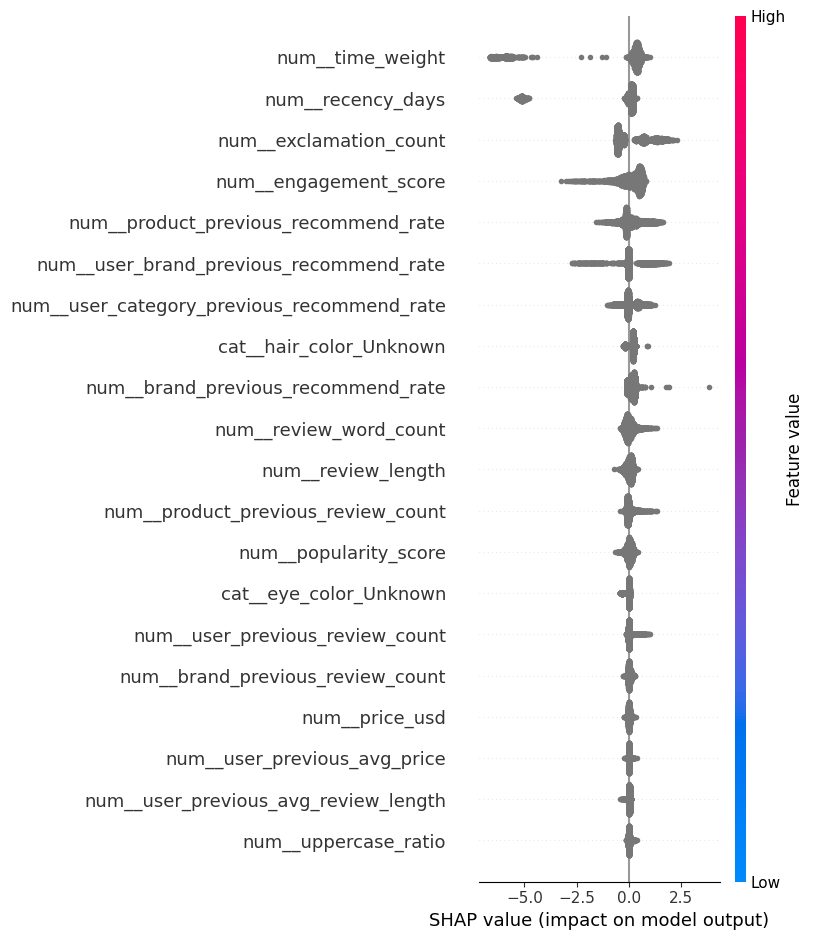

In [23]:
shap.summary_plot(

    shap_values_sample,

    X_test_sample,

    feature_names=shap_feature_names,

    max_display=20

)

red = high feature value
blue = low feature value
right side = increases recommendation probability
left side = decreases recommendation probability

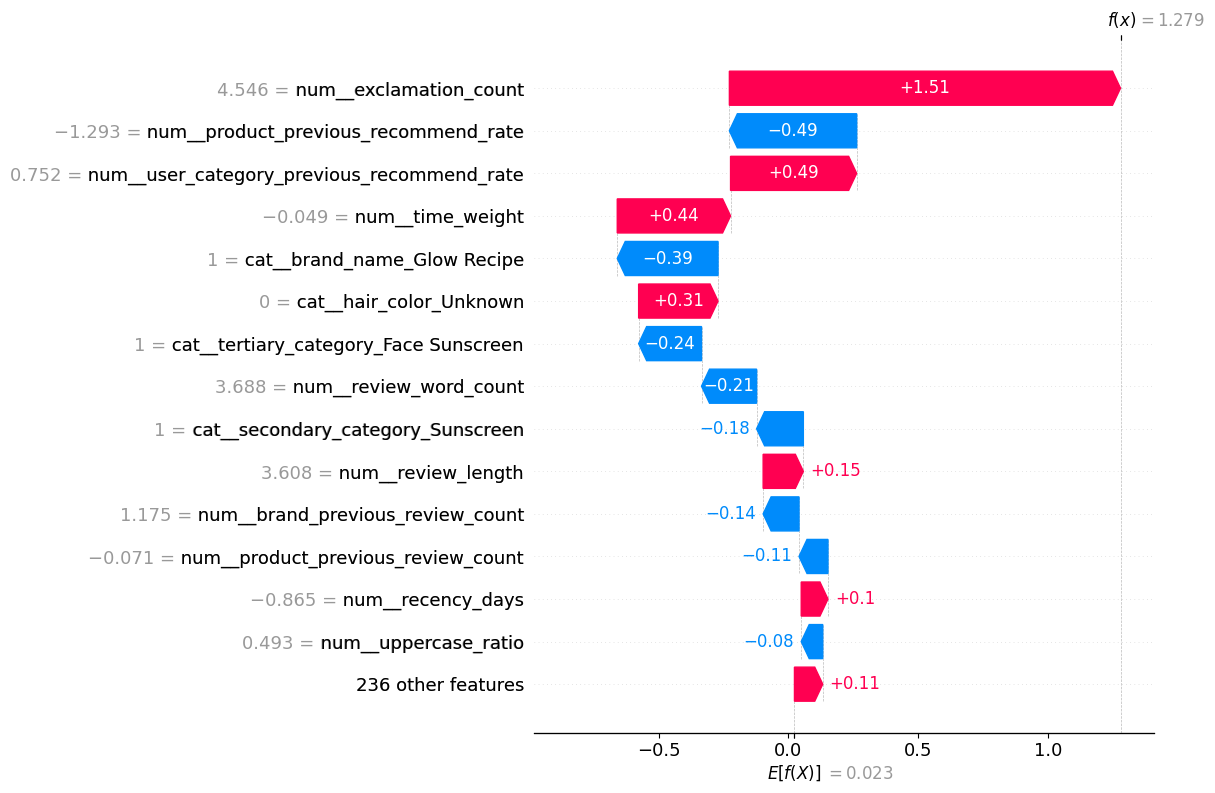

In [26]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_sample[sample_index],
        base_values=explainer.expected_value,
        data=sample_row,
        feature_names=shap_feature_names
    ),
    max_display=15
)

In [27]:
shap_importance.to_csv(
    feature_dir / "xgboost_shap_feature_importance.csv",
    index=False
)

In [28]:
import joblib


final_model_path = (
    model_dir /
    "final_recommendation_xgboostfinal_pipeline.pkl"
)


joblib.dump(
    best_xgb,
    final_model_path
)


print(
    "Saved:",
    final_model_path
)

Saved: c:\Users\ujjwa\OneDrive\Documents\beauty-recommender\models\final_recommendation_xgboostfinal_pipeline.pkl


In [30]:
print("ml_df exists:", "ml_df" in globals())
print("best_xgb exists:", "best_xgb" in globals())

ml_df exists: True
best_xgb exists: True


In [31]:
# Recreate feature matrix

feature_matrix = ml_df.drop(
    columns=["is_recommended"]
)


target = ml_df["is_recommended"]


print(feature_matrix.shape)

(1088891, 36)


In [32]:
categorical_features = feature_matrix.select_dtypes(
    include=["object","string"]
).columns.tolist()


numerical_features = feature_matrix.select_dtypes(
    include=np.number
).columns.tolist()


print(
    len(categorical_features),
    len(numerical_features)
)

8 28


In [34]:
import json


schema = {

    "features":
    feature_matrix.columns.tolist(),


    "categorical_features":
    categorical_features,


    "numerical_features":
    numerical_features

}


with open(
    model_dir / "feature_schema.json",
    "w"
) as f:

    json.dump(
        schema,
        f,
        indent=4
    )


print("Schema saved")

Schema saved


In [68]:
def predict_recommendation(
    input_data,
    model,
    threshold=0.60
):

    probability = (
        model
        .predict_proba(
            input_data
        )[:,1]
    )


    prediction = (
        probability >= threshold
    ).astype(int)


    return {

        "recommendation_probability":
        float(probability[0]),


        "prediction":
        int(prediction[0]),


        "threshold_used":
        threshold

    }

In [40]:
from xgboost import XGBClassifier


old_model = best_xgb.named_steps["model"]


new_model = XGBClassifier(

    n_estimators=old_model.n_estimators,

    learning_rate=old_model.learning_rate,

    max_depth=old_model.max_depth,

    subsample=old_model.subsample,

    colsample_bytree=old_model.colsample_bytree,

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1

)

In [41]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline


old_model = best_xgb.named_steps["model"]


fixed_xgb_model = XGBClassifier(

    n_estimators=old_model.n_estimators,

    learning_rate=old_model.learning_rate,

    max_depth=old_model.max_depth,

    subsample=old_model.subsample,

    colsample_bytree=old_model.colsample_bytree,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1

)


# replace model inside pipeline

best_xgb.steps[-1] = (
    "model",
    fixed_xgb_model
)


# retrain

best_xgb.fit(
    X_train,
    y_train
)


print("Pipeline repaired")

Pipeline repaired


In [69]:
sample_review = X_test.iloc[[10]]


prediction_result = predict_recommendation(
    sample_review,
    best_xgb
)


prediction_result

{'recommendation_probability': 0.8964282870292664,
 'prediction': 1,
 'threshold_used': 0.6}

In [43]:
joblib.dump(
    best_xgb,
    model_dir / "finalrepaired_recommendation_xgboost_pipeline.pkl"
)

print("Saved repaired pipeline")

Saved repaired pipeline


In [45]:
shap_importance.to_csv(

    model_dir /
    "shap_feature_importance.csv",

    index=False

)

In [54]:
# ============================================================
# FINAL MODEL PREDICTIONS
# ============================================================

best_pred = best_xgb.predict(
    X_test
)

best_prob = best_xgb.predict_proba(
    X_test
)[:,1]


print(best_pred[:10])
print(best_prob[:10])

[0 1 1 1 1 1 1 1 1 1]
[3.0425388e-05 8.9408630e-01 9.6228778e-01 9.1839784e-01 9.7432560e-01
 9.9098736e-01 8.4940779e-01 8.9044482e-01 9.7480166e-01 8.7147182e-01]


In [55]:
# ============================================================
# ERROR ANALYSIS DATASET
# ============================================================


error_df = X_test.copy()


error_df["actual"] = (
    y_test.values
)


error_df["prediction"] = (
    best_pred
)


error_df["probability"] = (
    best_prob
)


error_df.head()

,skin_tone,eye_color,skin_type,hair_color,engagement_score,review_length,recency_days,time_weight,price_usd,log_price,...,product_previous_recommend_rate,brand_previous_review_count,brand_previous_recommend_rate,user_brand_previous_count,user_brand_previous_recommend_rate,user_category_previous_count,user_category_previous_recommend_rate,actual,prediction,probability
134120,Unknown,Unknown,Unknown,Unknown,0,200,2283,0.000438,38.0,3.663562,...,0.839947,23527,0.839947,1,0.839947,1,0.839947,0.0,0,0.000030
361097,light,brown,dry,brown,0,99,1364,0.000733,33.0,3.526361,...,0.933333,20174,0.850060,0,0.839947,1,1.000000,1.0,1,0.894086
360731,fair,brown,combination,brown,0,189,1365,0.000732,44.0,3.806662,...,0.988636,3552,0.854038,0,0.839947,0,0.839947,1.0,1,0.962288
775521,light,green,normal,blonde,0,160,601,0.001661,60.0,4.110874,...,0.960988,20233,0.869429,0,0.839947,0,0.839947,1.0,1,0.918398
624414,lightMedium,brown,dry,brown,0,156,870,0.001148,32.0,3.496508,...,0.872387,10315,0.837227,0,0.839947,1,1.000000,1.0,1,0.974326


In [56]:
# ============================================================
# ERROR TYPES
# ============================================================


def classify_error(row):

    if row["actual"] == 1 and row["prediction"] == 1:
        return "True Positive"

    elif row["actual"] == 0 and row["prediction"] == 0:
        return "True Negative"

    elif row["actual"] == 1 and row["prediction"] == 0:
        return "False Negative"

    else:
        return "False Positive"



error_df["error_type"] = (
    error_df.apply(
        classify_error,
        axis=1
    )
)


error_df["error_type"].value_counts()

error_type
True Positive     151601
True Negative      42626
False Positive     19860
False Negative      3692
Name: count, dtype: int64

In [57]:
error_df["error_type"].value_counts()

error_type
True Positive     151601
True Negative      42626
False Positive     19860
False Negative      3692
Name: count, dtype: int64

In [58]:
false_positive_df = error_df[
    error_df["error_type"]=="False Positive"
]


false_positive_df.shape

(19860, 40)

In [59]:
false_positive_df.describe()

,engagement_score,review_length,recency_days,time_weight,price_usd,log_price,discount_amount,discount_pct,popularity_score,new,...,product_previous_recommend_rate,brand_previous_review_count,brand_previous_recommend_rate,user_brand_previous_count,user_brand_previous_recommend_rate,user_category_previous_count,user_category_previous_recommend_rate,actual,prediction,probability
count,19860.000000,19860.000000,19860.000000,19860.000000,19860.000000,19860.000000,19860.000000,19860.000000,19860.000000,19860.000000,...,19860.000000,19860.000000,19860.000000,19860.000000,19860.000000,19860.000000,19860.000000,19860.0,19860.0,19860.000000
mean,3.500050,320.080916,919.857100,0.004865,47.930445,3.653314,0.022709,0.050348,9.257326,0.017170,...,0.836901,12932.469537,0.835820,0.188520,0.836543,2.349043,0.773231,0.0,1.0,0.745798
std,17.062161,228.861534,522.048336,0.031491,39.097770,0.703726,0.829086,1.589441,1.321489,0.129909,...,0.099111,10360.608442,0.051797,0.668475,0.114245,7.845968,0.264910,0.0,0.0,0.133714
min,-265.000000,0.000000,0.000000,0.000492,3.000000,1.386294,0.000000,0.000000,0.778364,0.000000,...,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.500001
25%,0.000000,166.000000,485.000000,0.000764,24.000000,3.218876,0.000000,0.000000,8.408895,0.000000,...,0.784091,4319.500000,0.806131,0.000000,0.839947,0.000000,0.839947,0.0,1.0,0.633841
50%,1.000000,264.000000,933.000000,0.001071,39.000000,3.688879,0.000000,0.000000,9.315683,0.000000,...,0.848617,10894.500000,0.834242,0.000000,0.839947,0.000000,0.839947,0.0,1.0,0.746926
75%,3.000000,407.000000,1308.250000,0.002058,62.000000,4.143135,0.000000,0.000000,10.156907,0.000000,...,0.906250,19203.500000,0.865670,0.000000,0.839947,2.000000,0.839947,0.0,1.0,0.857958
max,975.000000,2000.000000,2030.000000,1.000000,449.000000,6.109248,54.000000,58.064516,12.211315,1.000000,...,1.000000,48308.000000,1.000000,15.000000,1.000000,276.000000,1.000000,0.0,1.0,0.998884


In [60]:
false_negative_df = error_df[
    error_df["error_type"]=="False Negative"
]


false_negative_df.shape

(3692, 40)

In [61]:
uncertain_predictions = error_df[
    (error_df["probability"] > 0.4)
    &
    (error_df["probability"] < 0.6)
]


uncertain_predictions.shape

(11993, 40)

In [62]:
true_positive = (
    error_df[
        error_df["error_type"]
        ==
        "True Positive"
    ]
)


true_positive[
[
"price_usd",
"popularity_score",
"user_previous_review_count",
"product_previous_review_count"
]
].mean()

price_usd                          50.337680
popularity_score                    9.125847
user_previous_review_count          3.957480
product_previous_review_count    1096.416066
dtype: float64

In [63]:
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)


threshold_results = []


thresholds = np.arange(
    0.1,
    0.91,
    0.05
)


for threshold in thresholds:

    predictions = (
        best_prob >= threshold
    ).astype(int)


    threshold_results.append({

        "threshold": threshold,

        "precision":
        precision_score(
            y_test,
            predictions
        ),

        "recall":
        recall_score(
            y_test,
            predictions
        ),

        "f1":
        f1_score(
            y_test,
            predictions
        )

    })


threshold_df = pd.DataFrame(
    threshold_results
)


threshold_df

,threshold,precision,recall,f1
0,0.10,0.852325,0.999543,0.920082
1,0.15,0.856584,0.998828,0.922253
2,0.20,0.860293,0.997708,0.923919
3,0.25,0.863356,0.996201,0.925033
4,0.30,0.866478,0.994642,0.926147
5,0.35,0.869714,0.992163,0.926912
6,0.40,0.873683,0.988718,0.927648
7,0.45,0.878568,0.983605,0.928124
8,0.50,0.884172,0.976226,0.927921
9,0.55,0.891464,0.965304,0.926916


In [64]:
best_threshold = (
    threshold_df
    .sort_values(
        "f1",
        ascending=False
    )
    .iloc[0]
)

In [65]:
best_threshold

threshold    0.450000
precision    0.878568
recall       0.983605
f1           0.928124
Name: 7, dtype: float64

In [66]:
threshold_df[
    threshold_df["recall"] >= 0.85
]

,threshold,precision,recall,f1
0,0.10,0.852325,0.999543,0.920082
1,0.15,0.856584,0.998828,0.922253
2,0.20,0.860293,0.997708,0.923919
3,0.25,0.863356,0.996201,0.925033
4,0.30,0.866478,0.994642,0.926147
5,0.35,0.869714,0.992163,0.926912
6,0.40,0.873683,0.988718,0.927648
7,0.45,0.878568,0.983605,0.928124
8,0.50,0.884172,0.976226,0.927921
9,0.55,0.891464,0.965304,0.926916


In [67]:
import json


threshold_config = {

    "classification_threshold": 0.60,

    "selection_reason":
    "Chosen to maximize recommendation precision while maintaining high recall"

}


with open(
    model_dir / "threshold.json",
    "w"
) as f:

    json.dump(
        threshold_config,
        f,
        indent=4
    )